In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import glob
import tqdm


In [32]:
etam_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/etam_m6a.transcript.tsv", sep="\t")
print(etam_df)

          chr strand       pos  methylation chrstrand          NMID  \
0       chr20      -  51390746      39.8780    chr20-  NM_001258295   
1       chr20      -  51390746      39.8780    chr20-  NM_001258294   
2       chr20      -  51390746      39.8780    chr20-  NM_001258292   
3       chr20      -  51390746      39.8780    chr20-  NM_001136021   
4       chr20      -  51390746      39.8780    chr20-  NM_001258297   
...       ...    ...       ...          ...       ...           ...   
290717   chr3      -  15669928      50.3564     chr3-  NM_001349281   
290718   chr3      -  15669928      50.3564     chr3-  NM_001349282   
290719   chr3      -  15669928      50.3564     chr3-  NM_001349278   
290720   chr3      -  15669928      50.3564     chr3-  NM_001349277   
290721   chr3      -  15669928      50.3564     chr3-  NM_001195099   

        transcript_coordinate  
0                        3062  
1                        3150  
2                        3576  
3                  

In [33]:
other_df = pd.read_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/GLORI_unconv5nt.tsv", sep="\t")

In [34]:
print(other_df)

           chr str       pos       DoM    SAC  GLORI  MICLIP2  M6ACE  \
0        chr19   +  55483246  0.000000  False  False    False   True   
1        chr19   +  55483285  0.000000  False  False    False   True   
2        chr19   +  55483315  0.364375  False   True     True   True   
3        chr19   +  55483323  0.983865  False   True     True  False   
4        chr19   +  55483341  0.122675  False   True     True  False   
...        ...  ..       ...       ...    ...    ...      ...    ...   
2565428  chr17   -  60055563  0.000000  False  False     True  False   
2565429  chr17   -  60056203  0.000000  False  False     True  False   
2565430  chr17   -  60057126  0.000000   True  False    False  False   
2565431  chr17   -  60057227  0.083093  False   True    False  False   
2565432  chr17   -  60057296  0.321984  False   True    False  False   

         validated chrstrand       NMID  transcript_coordinate  
0                1    chr19+  NM_033113                   2321  
1    

In [35]:
other_df = other_df[["SAC", "MICLIP2", "M6ACE", "NMID", "transcript_coordinate"]]
other_df = other_df[other_df[["SAC", "MICLIP2", "M6ACE"]].any(axis=1)]
print(other_df)

           SAC  MICLIP2  M6ACE       NMID  transcript_coordinate
0        False    False   True  NM_033113                   2321
1        False    False   True  NM_033113                   2360
2        False     True   True  NM_033113                   2390
3        False     True  False  NM_033113                   2398
4        False     True  False  NM_033113                   2416
...        ...      ...    ...        ...                    ...
2565426   True    False  False  NM_022070                   2573
2565427   True    False  False  NM_022070                   2255
2565428  False     True  False  NM_022070                   2246
2565429  False     True  False  NM_022070                   2119
2565430   True    False  False  NM_022070                   2006

[2141325 rows x 5 columns]


In [36]:
etam_df  = etam_df[["methylation", "NMID", "transcript_coordinate"]]
etam_df["ETAM"] = True
etam_df["NMID"] = etam_df["NMID"].str.split(".").str[0]
etam_df.rename(columns={"methylation": "DoM"}, inplace=True)

print(etam_df)


            DoM          NMID  transcript_coordinate  ETAM
0       39.8780  NM_001258295                   3062  True
1       39.8780  NM_001258294                   3150  True
2       39.8780  NM_001258292                   3576  True
3       39.8780  NM_001136021                   3664  True
4       39.8780  NM_001258297                   3132  True
...         ...           ...                    ...   ...
290717  50.3564  NM_001349281                   4377  True
290718  50.3564  NM_001349282                   4386  True
290719  50.3564  NM_001349278                   5050  True
290720  50.3564  NM_001349277                   5059  True
290721  50.3564  NM_001195099                   3376  True

[290722 rows x 4 columns]


In [37]:
joint_df = pd.merge(etam_df, other_df, on=["NMID", "transcript_coordinate"], how="outer")
print(joint_df)

            DoM          NMID  transcript_coordinate  ETAM    SAC MICLIP2  \
0        39.878  NM_001258295                   3062  True    NaN     NaN   
1        39.878  NM_001258294                   3150  True    NaN     NaN   
2        39.878  NM_001258292                   3576  True    NaN     NaN   
3        39.878  NM_001136021                   3664  True    NaN     NaN   
4        39.878  NM_001258297                   3132  True    NaN     NaN   
...         ...           ...                    ...   ...    ...     ...   
2268860     NaN     NM_022070                   2573   NaN   True   False   
2268861     NaN     NM_022070                   2255   NaN   True   False   
2268862     NaN     NM_022070                   2246   NaN  False    True   
2268863     NaN     NM_022070                   2119   NaN  False    True   
2268864     NaN     NM_022070                   2006   NaN   True   False   

         M6ACE  
0          NaN  
1          NaN  
2          NaN  
3      

In [38]:
joint_df["DoM"] = joint_df["DoM"].fillna(0)
joint_df["ETAM"] = joint_df["ETAM"].fillna(False)
joint_df["SAC"] = joint_df["SAC"].fillna(False)
joint_df["MICLIP2"] = joint_df["MICLIP2"].fillna(False)
joint_df["M6ACE"] = joint_df["M6ACE"].fillna(False)

print(joint_df)

            DoM          NMID  transcript_coordinate   ETAM    SAC  MICLIP2  \
0        39.878  NM_001258295                   3062   True  False    False   
1        39.878  NM_001258294                   3150   True  False    False   
2        39.878  NM_001258292                   3576   True  False    False   
3        39.878  NM_001136021                   3664   True  False    False   
4        39.878  NM_001258297                   3132   True  False    False   
...         ...           ...                    ...    ...    ...      ...   
2268860   0.000     NM_022070                   2573  False   True    False   
2268861   0.000     NM_022070                   2255  False   True    False   
2268862   0.000     NM_022070                   2246  False  False     True   
2268863   0.000     NM_022070                   2119  False  False     True   
2268864   0.000     NM_022070                   2006  False   True    False   

         M6ACE  
0        False  
1        False  


In [39]:
joint_df["validated"] = joint_df[["SAC", "MICLIP2", "M6ACE", "ETAM"]].sum(axis=1)
print(joint_df["validated"].value_counts())
joint_df["DoM"] = joint_df["DoM"] / 100

joint_df.to_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/m6A_HeLa_v2.tsv", sep="\t", index=False)

validated
1    1950115
2     231782
3      71078
4      15890
Name: count, dtype: int64


In [10]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/Baeklab.070.eTAM.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[(label_df["dom_label"] > 0.0) | (label_df["label"] == 0)].copy()
label_df_filtered["label"] = label_df_filtered["dom_label"] > 0.0
print(label_df_filtered["label"].value_counts())



label
False    12230399
True       103542
Name: count, dtype: int64


In [11]:
cell_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(cell_df, allow_pickle=True) as data:
    cell_df = pd.DataFrame({key: data[key] for key in data.keys()})
cell_df = cell_df[cell_df["count_dom"] >= 20]
print(cell_df)

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
30894417    NR_184306:85   1.133184      0.000000        0.000000          0   
30894420    NR_184306:87   3.771550     -0.001452       -2.476578          1   
30894423    NR_184306:88   2.137289      0.000000        0.000000          0   
30894435    NR_184306:93  32.341377     -0.011076      -78.301079         23   
30894446    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [12]:
cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")
print(cell_label_df)

               label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0        NM_000016:1000   0.606511      0.000000        0.000000          0   
1        NM_000016:1008   0.948786      0.000000        0.000000          0   
2        NM_000016:1009   2.607620      0.000000        0.000000          0   
3        NM_000016:1010   4.912612      0.000000        0.000000          0   
4        NM_000016:1014   3.237954      0.000000        0.000000          0   
...                 ...        ...           ...             ...        ...   
7831386  NR_182669:3969   1.723521      0.000000        0.000000          0   
7831387  NR_182751:2277   8.478946     -0.009655      -19.475899          7   
7831388   NR_182751:506   1.901786      0.000000        0.000000          0   
7831389  NR_182754:2730   1.667113      0.000000        0.000000          0   
7831390   NR_183625:499  23.870399     -0.014579      -64.044052         21   

         logsum_p_neg  logsum_1_p_neg  count_neg  l

In [13]:
cell_label_df["pm6a"] =  -(2-cell_label_df["dom"])*cell_label_df["logsum_1_p_pos"]/cell_label_df["count_all"] + ((1-cell_label_df["dom"])*np.log10(np.clip(1-cell_label_df["dom"],1e-30,1)) + cell_label_df["dom"] * np.log10(np.clip(cell_label_df["dom"],1e-30,1)))*(cell_label_df["count_pos"]/cell_label_df["count_all"])

In [14]:
## Plot scatter
cell_label_df["dom_threshold"] = np.log10(0.02)*(cell_label_df["dom"]) > cell_label_df["logsum_1_p_pos"]/cell_label_df["count_dom"]

selected_df = cell_label_df[ (cell_label_df["dom_threshold"])]
print(selected_df)

               label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
66       NM_000016:1218   3.342309     -0.013035       -6.126953          3   
73       NM_000016:1232   1.903287     -0.002427       -2.254001          1   
78       NM_000016:1244   4.040272     -0.000032       -4.128505          1   
79       NM_000016:1245   4.232924     -0.001182       -5.788179          2   
97       NM_000016:1302  59.435646     -0.070924     -143.232574         53   
...                 ...        ...           ...             ...        ...   
7831314  NR_182669:3702   1.442454     -0.002071       -2.322619          1   
7831344  NR_182669:3813   1.035196     -0.000701       -2.792167          1   
7831374  NR_182669:3949   4.004800     -0.013700       -9.599714          4   
7831387  NR_182751:2277   8.478946     -0.009655      -19.475899          7   
7831390   NR_183625:499  23.870399     -0.014579      -64.044052         21   

         logsum_p_neg  logsum_1_p_neg  count_neg  l

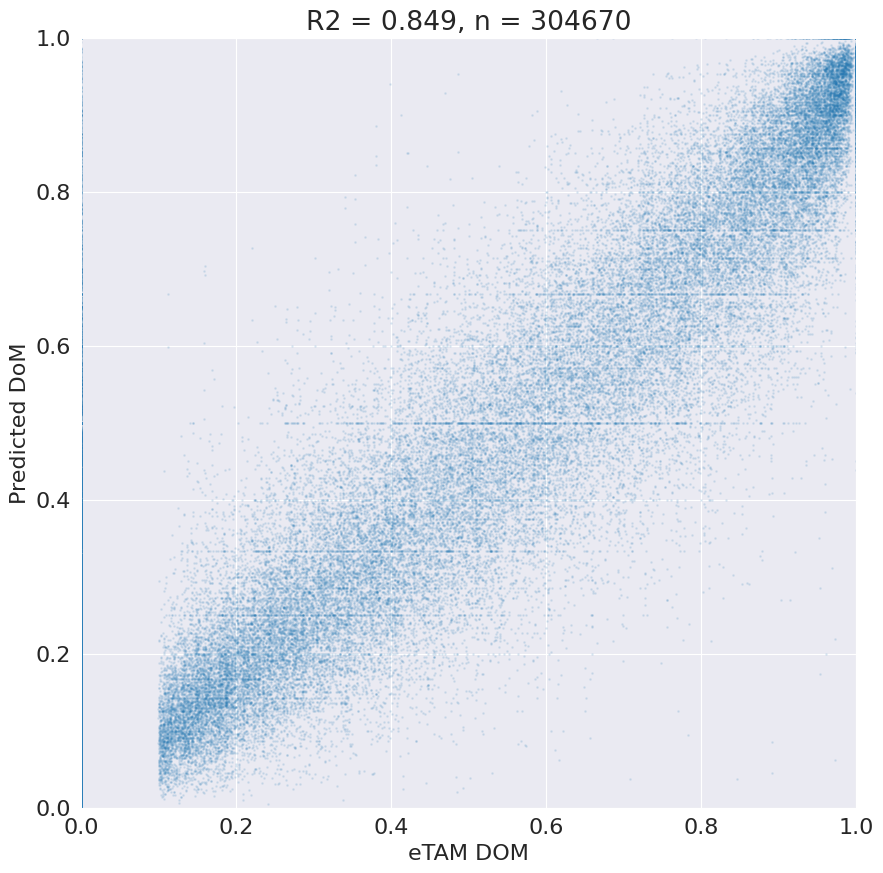

In [17]:
plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}, n = {len(selected_df)}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()


In [16]:
cell_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_dwell_bq_npz-ON0091_allmotif_pileup/pileup.pkl")
cell_df = cell_df[cell_df["count_all"] >= 20]
print(cell_df)

cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")
print(cell_label_df)


KeyError: 'count_all'

               label_id      pm6a  count_pm6a       dom  count_dom  mean_pred  \
97       NM_000016:1302  0.828286       295.0  0.263158        304   0.264927   
307      NM_000016:1882  0.387690       296.0  0.086093        302   0.089166   
841      NM_000021:1584  0.998911        88.0  0.921348         89   0.918813   
860      NM_000021:1641  0.583695        82.0  0.137931         87   0.136244   
862      NM_000021:1655  0.956187        76.0  0.488636         88   0.480976   
...                 ...       ...         ...       ...        ...        ...   
6951019  NR_184208:2817  0.222229       124.0  0.038168        131   0.046613   
6951034  NR_184208:2919  0.670510        99.0  0.206897        116   0.211380   
6951066  NR_184208:3139  0.511927       121.0  0.120301        133   0.124006   
6951074  NR_184208:3186  0.646963        96.0  0.178571        112   0.192851   
6951176   NR_184208:802  0.222232        30.0  0.033333         30   0.038873   

         depth  label  dom_

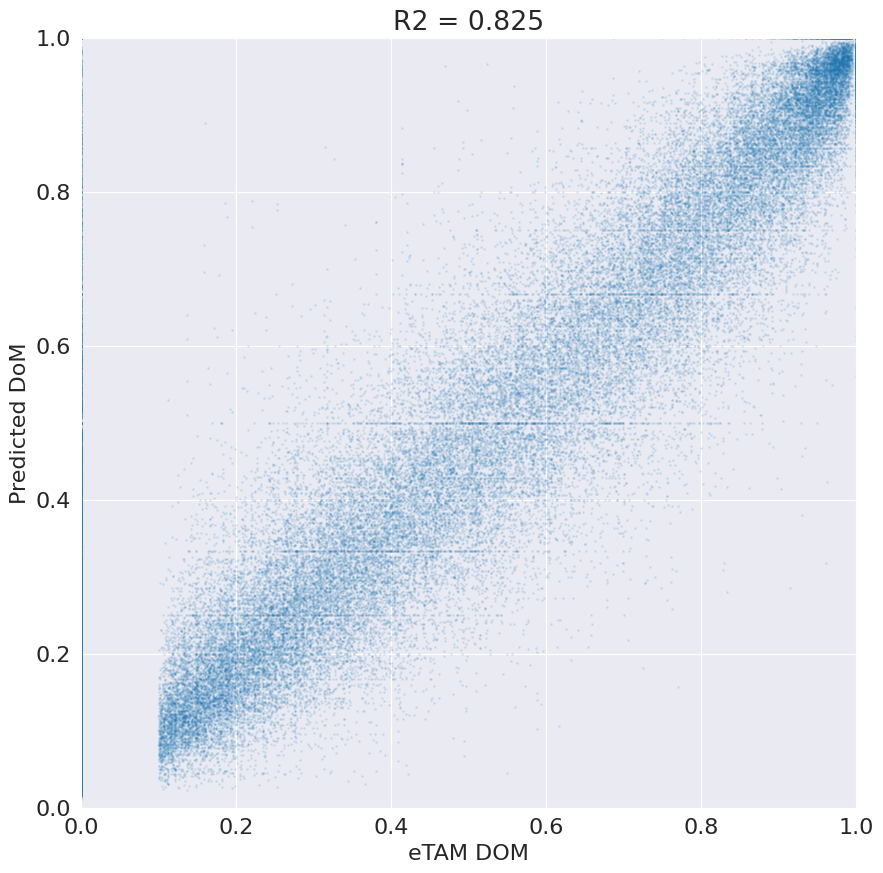

In [49]:
## Plot scatter
cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
selected_df = cell_label_df[(cell_label_df["pm6a"] > cell_label_df["threshold"])]
print(selected_df)

plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()


In [50]:


def process_dorado_inferece(data_path):
    if data_path is None:
        return None
    if os.path.exists(data_path.replace(".bed", ".drach.pkl")):
        data_df = pd.read_pickle(data_path.replace(".bed", ".drach.pkl"))
    elif os.path.exists(data_path.replace(".bed", ".pkl")):
        data_df = pd.read_pickle(data_path.replace(".bed", ".pkl"))
    else:
        data_df = pd.read_csv(data_path, quoting = 3, sep = "\t", header = None, dtype=str)
        ## Keep column 0, 1, 4, 9
        data_df = data_df[[0, 1, 4, 9]]
        data_df.columns = ["nmid", "pos", "depth", "pred_dorado"]
        data_df["depth"] = data_df["depth"].astype(int)
        data_df["pred_dorado"] = data_df["pred_dorado"].str.split(" ").str[1].astype(float) / 100
        data_df["label_id"] = data_df["nmid"].str.split(".").str[0] + ":" + data_df["pos"]
        data_df = data_df[["label_id", "pred_dorado","depth"]].copy()
        data_df.rename(columns = {"depth": "dorado_count"}, inplace = True)
        data_df.to_pickle(data_path.replace(".bed", ".pkl"))

    return data_df

In [51]:
dorado_df = process_dorado_inferece("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/dorado-070-aligned/intermediates/dorado_output.modkit.bed")

In [ ]:
print(dorado_df)
dorado_label_df = dorado_df.merge(label_df_filtered, on="label_id", how="inner")
print(dorado_label_df)

In [57]:
dorado_label_df = dorado_label_df[dorado_label_df["dorado_count"] >= 20]

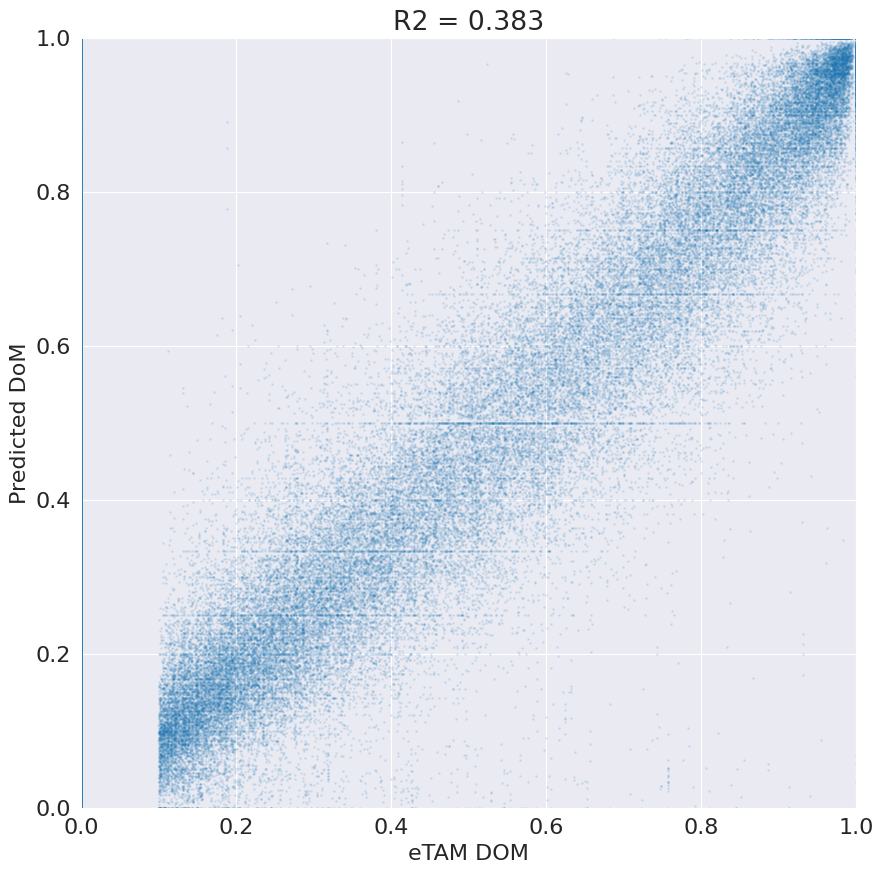

In [58]:
selected_df = dorado_label_df

plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["pred_dorado"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["pred_dorado"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()


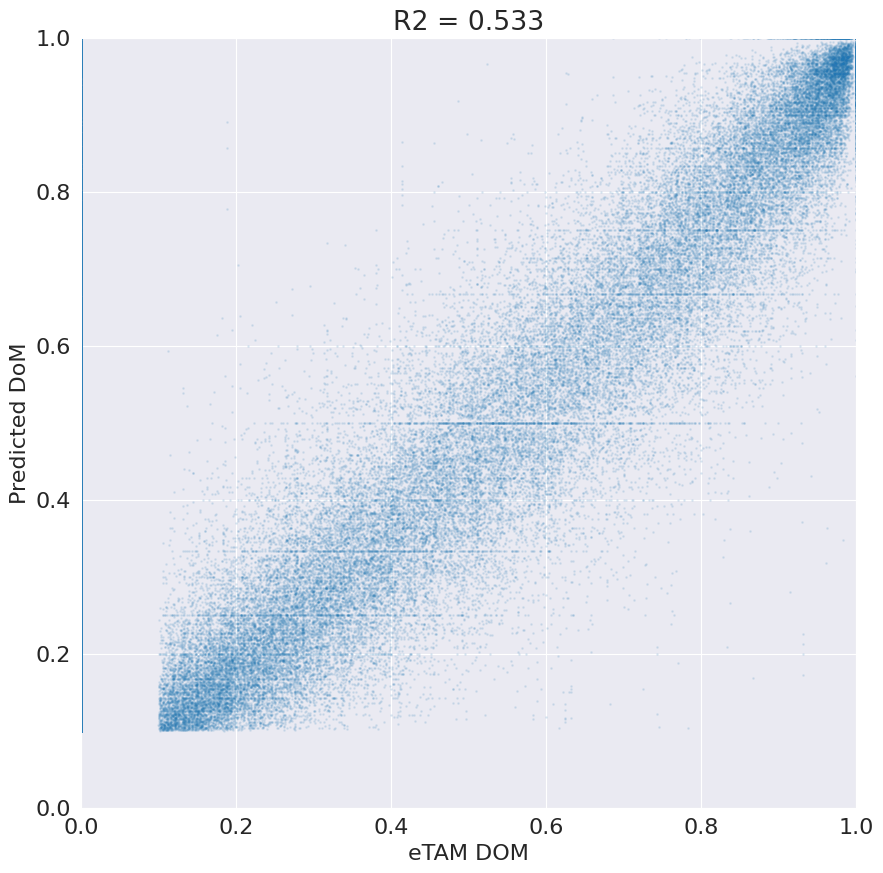

In [59]:
selected_df = dorado_label_df[dorado_label_df["pred_dorado"] > 0.1]

plt.rcParams.update({'font.size': 16})

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["pred_dorado"], alpha=0.1, s = 1)
ax.set_xlabel("eTAM DOM")
ax.set_ylabel("Predicted DoM")
r2 = pearsonr(selected_df["dom_label"], selected_df["pred_dorado"])[0] ** 2
ax.set_title(f"R2 = {r2:.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()
